<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/4.2-fine-tuning-png-vs-tensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fine-Tuning with ResNet-18 and EfficientNet-B0

### Introduction: PNG vs. Tensor

This is the stage before selecting the best model for **Speech Emotion Recognition (SER)**. In this notebook, we train models using two different input approaches:

1. **Images (PNG):** Mel spectrograms previously generated and saved as image files.
2. **3D Tensors:** Data processed directly with PyTorch from **Cepstral Coefficients (MFCCs)** and their **first- and second-order deltas**. This produces an input tensor with shape `[3, Frequency, Time]`.

We analyze performance metrics, computational costs, and above all the reach of models trained on compressed images compared with those trained on tensors, which preserve the information and temporal dimension in their inputs more faithfully.

In [1]:
# Imports
#----------------------------------------------------------------
import os
import gc
import numpy as np
import glob
import torch
import random
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
#----------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Optimizaciones de hardware y fijación de semillas para reproducibilidad
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device en uso: {device}")

Device en uso: cuda


In [4]:
# Copy the entire features folder from Drive to Colab's ultra-fast disk
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local
os.makedirs('/content/ravdess_and_crema_images', exist_ok=True)
#os.makedirs('/content/data_split_tensors', exist_ok=True)
# Optional: If you have a .zip file in Drive, it is EVEN FASTER to copy the .zip and unzip it locally:
!cp /content/drive/MyDrive/mel_spec_and_mfcc_images.zip /content/mel_spec_mfcc_images.zip
!cp -r /content/drive/MyDrive/data_split_tensors/ /content

!unzip -q /content/mel_spec_mfcc_images.zip -d /content/ravdess_and_crema_images

In [5]:
# Configuraciones y rutas
BASE_DIR_IMG = '/content/ravdess_and_crema_images'
BASE_DIR_TENSOR = '/content/data_split_tensors'
MODELS_SAVE_DIR = '/content/saved_models'
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64 # Ajustable si hay problemas de memoria con DenseNet (Spoiler: Dejar en 64)

# It is recommended to use the GPU provided by Google Colab to speed up training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
# Print root_dir content:
img_content = (os.listdir(BASE_DIR_IMG))
tensor_content = (os.listdir(BASE_DIR_TENSOR))

print(f"Contenido de {BASE_DIR_IMG}: {img_content}")
print(f"Contenido de {BASE_DIR_TENSOR}: {tensor_content}")

Contenido de /content/ravdess_and_crema_images: ['mfcc', 'mel_spec']
Contenido de /content/data_split_tensors: ['train_tensors.pt', 'test_tensors.pt', 'val_tensors.pt']


### Dataloaders from split data (Train, Validation, Test)

In [7]:
def get_images_dataloaders(feature_type):


  """
  Construye DataLoaders aislando Train/Val/Test.
  Aplica normalización de ImageNet estrictamente necesaria para el Transfer Learning.
  Nota: ImageFolder convierte automáticamente RGBA a RGB (fondo negro) por defecto.
  """
  feature_dir_img = os.path.join(BASE_DIR_IMG, feature_type)

  transform_pipeline = transforms.Compose([
      #transforms.Resize(224,224), # Cambiar si la imagen de origen no es 224x224
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  ])

  datasets_dict = {}
  for split in ['train', 'val', 'test']:
      split_path = os.path.join(feature_dir_img, split)
      datasets_dict[split] = datasets.ImageFolder(root=split_path, transform=transform_pipeline)


  # Optimizaciones: num_workers=2 y pin_memory=True aceleran la transferencia a la GPU
  train_loader = DataLoader(datasets_dict['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
  val_loader = DataLoader(datasets_dict['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
  test_loader = DataLoader(datasets_dict['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

  class_names = datasets_dict['train'].classes
  print(f"[{feature_type.upper()}] Clases detectadas: {class_names}")
  print(f"Muestras -> Train: {len(datasets_dict['train'])} | Val: {len(datasets_dict['val'])} | Test: {len(datasets_dict['test'])}")

  return train_loader, val_loader, test_loader, class_names

In [8]:
get_images_dataloaders("mfcc")

[MFCC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895


(<torch.utils.data.dataloader.DataLoader at 0x7eaf6ab2a390>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

In [9]:
# Mapea índices a clases igual que en extracción
IDX_TO_CLASS = {
    0: 'angry',
    1: 'disgust',
    2: 'fearful',
    3: 'happy',
    4: 'neutral',
    5: 'sad',
    6: 'surprised'
}

CLASS_NAMES = list(IDX_TO_CLASS.values())

def get_tensors_dataloaders(BASE_DIR_TENSOR, BATCH_SIZE):
    datasets_dict = {}

    file_map = {
        'train': 'train_tensors.pt',
        'val': 'val_tensors.pt',
        'test': 'test_tensors.pt'
    }

    for split, filename in file_map.items():
        split_path = os.path.join(BASE_DIR_TENSOR, filename)
        if not os.path.exists(split_path):
            raise FileNotFoundError(f"No existe el archivo de split: {split_path}")
        datasets_dict[split] = torch.load(split_path)

    # Si usas GPU, pin_memory ayuda; en CPU no aporta
    pin = torch.cuda.is_available()

    train_loader = DataLoader(
        datasets_dict['train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=pin
    )
    val_loader = DataLoader(
        datasets_dict['val'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=pin
    )
    test_loader = DataLoader(
        datasets_dict['test'],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=pin
    )

    class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]

    print(f"Clases detectadas: {class_names}")
    print(
        f"Muestras -> Train: {len(datasets_dict['train'])} | "
        f"Val: {len(datasets_dict['val'])} | "
        f"Test: {len(datasets_dict['test'])}"
    )

    # sanity check de forma del primer tensor
    x0, y0 = datasets_dict['train'][0]
    print(f"Shape ejemplo train[0]: {tuple(x0.shape)} | label={y0}")

    return train_loader, val_loader, test_loader, class_names


In [10]:
get_tensors_dataloaders(BASE_DIR_TENSOR, BATCH_SIZE)

Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7422 | Val: 830 | Test: 918
Shape ejemplo train[0]: (3, 13, 94) | label=3


(<torch.utils.data.dataloader.DataLoader at 0x7eaf6a628050>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

### Model Factory for Tensors

ResNet18 y Efficientnet-b0

In [11]:
class TensorModelFactory:
  @staticmethod
  def get_model(model_name: str, num_classes: int, freeze_base: bool=True):
    if model_name == 'resnet18':
      model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
      # Adaptacion para input pequeño [3,13,94]
      model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
      model.maxpool = nn.Identity()
      if freeze_base:
        for param in model.parameters():
          param.requires_grad = False

      in_features = model.fc.in_features
      model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_features, num_classes))

    elif model_name == 'efficientnet_b0':
      model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)


      if freeze_base:
          for p in model.parameters():
              p.requires_grad = False

      in_f = model.classifier[1].in_features
      model.classifier = nn.Sequential(
          nn.Dropout(0.4),
          nn.Linear(in_f, num_classes)
      )

    else:
        raise ValueError(f"Modelo no soportado para tensor pipeline: {model_name}")

    return model.to(device)

### Neural network training

Funcion para entrenar con ResNet o Efficientnet-b0, las funciones de entrenamiento de modelos son muy similares, en ellas podremos configurar los parametros de la red, por ejemplo:
* Directorio donde guaramos  los modelos `save_path`,
* Numero de epocas `epochs`,
* Learning rate o taza de aprendizaje `lr`,
* Numero de intentos antes de detener el entrenamiento `patience`,
* Configuracion de los pesos `weight_decay`.


In [12]:

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def cleanup_state():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def train_model_tensor(
    model,
    train_loader,
    val_loader,
    save_path,
    epochs=20,
    lr=1e-3,
    patience=4,
    weight_decay=1e-2
):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)

    # scheduler maximiza F1 macro
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    # best checkpoint por F1 macro
    best_val_f1 = -1.0
    trigger = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)

        train_loss /= max(train_total, 1)
        train_acc = train_correct / max(train_total, 1)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_val_y, all_val_p = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(x)
                    loss = criterion(logits, y)

                val_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)

                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                all_val_y.extend(y.cpu().numpy())
                all_val_p.extend(preds.cpu().numpy())

        val_loss /= max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)
        val_f1_macro = f1_score(all_val_y, all_val_p, average='macro')

        scheduler.step(val_f1_macro)
        lr_now = optimizer.param_groups[0]['lr']

        print(f"[{epoch+1:02d}/{epochs}] lr={lr_now:.1e} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f} f1m={val_f1_macro:.4f}")

        if val_f1_macro > best_val_f1:
            best_val_f1 = val_f1_macro
            torch.save(model.state_dict(), save_path)
            trigger = 0
        else:
            trigger += 1
            print(f"Early stop activado: {trigger}/{patience}")
            if trigger >= patience:
                print("Early stopping.")
                break

    return save_path

Ejecución de entrenamiento

In [13]:
# Limpieza del estado para evitar resultados por memorizacion
set_global_seed(42)
cleanup_state()

In [14]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_1 = 'efficientnet_b0'
exp_name_b0 = f"tensor{MODEL_ARCH_1}"

train_loader, val_loader, test_loader, class_names = get_tensors_dataloaders(
    BASE_DIR_TENSOR,
    BATCH_SIZE
)

phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}efficient_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_1, num_classes=len(CLASS_NAMES), freeze_base=True)

best_phase1_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=15,
    lr=1e-3,
    patience=4
)

print("Fase 1 mejor modelo:", best_phase1_eff)

Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7422 | Val: 830 | Test: 918
Shape ejemplo train[0]: (3, 13, 94) | label=3
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 160MB/s]


[01/15] lr=1.0e-03 | train_loss=1.9140 acc=0.2033 | val_loss=1.7967 acc=0.2470 f1m=0.2397
[02/15] lr=1.0e-03 | train_loss=1.8080 acc=0.2604 | val_loss=1.7903 acc=0.2639 f1m=0.2540
[03/15] lr=1.0e-03 | train_loss=1.7724 acc=0.2750 | val_loss=1.7862 acc=0.2687 f1m=0.2577
[04/15] lr=1.0e-03 | train_loss=1.7593 acc=0.2824 | val_loss=1.7709 acc=0.2663 f1m=0.2602
[05/15] lr=1.0e-03 | train_loss=1.7702 acc=0.2859 | val_loss=1.7848 acc=0.2687 f1m=0.2613
[06/15] lr=1.0e-03 | train_loss=1.7498 acc=0.2894 | val_loss=1.7938 acc=0.2542 f1m=0.2530
Early stop activado: 1/4
[07/15] lr=1.0e-03 | train_loss=1.7576 acc=0.2917 | val_loss=1.7914 acc=0.2747 f1m=0.2591
Early stop activado: 2/4
[08/15] lr=5.0e-04 | train_loss=1.7426 acc=0.3048 | val_loss=1.7827 acc=0.2651 f1m=0.2602
Early stop activado: 3/4
[09/15] lr=5.0e-04 | train_loss=1.7344 acc=0.2945 | val_loss=1.7797 acc=0.2542 f1m=0.2447
Early stop activado: 4/4
Early stopping.
Fase 1 mejor modelo: /content/saved_models/tensorefficientnet_b0efficient_

In [15]:
# Descongelamiento de las capas de la CNN
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_b0}_fase2.pth")

model.load_state_dict(torch.load(best_phase1_eff, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_phase2_eff = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=25,
    lr=1e-5,
    patience=4
)

print("Fase 2 mejor modelo efficient:", best_phase2_eff)

[01/25] lr=1.0e-05 | train_loss=1.7387 acc=0.3002 | val_loss=1.7682 acc=0.2795 f1m=0.2723
[02/25] lr=1.0e-05 | train_loss=1.7081 acc=0.3123 | val_loss=1.7638 acc=0.2916 f1m=0.2843
[03/25] lr=1.0e-05 | train_loss=1.6795 acc=0.3270 | val_loss=1.7551 acc=0.2867 f1m=0.2772
Early stop activado: 1/4
[04/25] lr=1.0e-05 | train_loss=1.6652 acc=0.3319 | val_loss=1.7491 acc=0.2855 f1m=0.2782
Early stop activado: 2/4
[05/25] lr=1.0e-05 | train_loss=1.6437 acc=0.3494 | val_loss=1.7374 acc=0.2964 f1m=0.2843
[06/25] lr=1.0e-05 | train_loss=1.6359 acc=0.3499 | val_loss=1.7227 acc=0.2976 f1m=0.2884
[07/25] lr=1.0e-05 | train_loss=1.6186 acc=0.3542 | val_loss=1.7245 acc=0.2904 f1m=0.2814
Early stop activado: 1/4
[08/25] lr=1.0e-05 | train_loss=1.5986 acc=0.3733 | val_loss=1.7144 acc=0.3000 f1m=0.2909
[09/25] lr=1.0e-05 | train_loss=1.5838 acc=0.3647 | val_loss=1.7092 acc=0.3000 f1m=0.2883
Early stop activado: 1/4
[10/25] lr=1.0e-05 | train_loss=1.5722 acc=0.3828 | val_loss=1.7019 acc=0.3241 f1m=0.3081


Evalucion del modelo

Test Accuracy: 0.2963 | Test F1 macro: 0.2820

              precision    recall  f1-score   support

       angry       0.40      0.55      0.47       150
     disgust       0.27      0.19      0.22       150
     fearful       0.29      0.21      0.24       150
       happy       0.24      0.16      0.19       150
     neutral       0.27      0.21      0.23       144
         sad       0.30      0.41      0.34       150
   surprised       0.18      0.62      0.28        24

    accuracy                           0.30       918
   macro avg       0.28      0.34      0.28       918
weighted avg       0.29      0.30      0.28       918



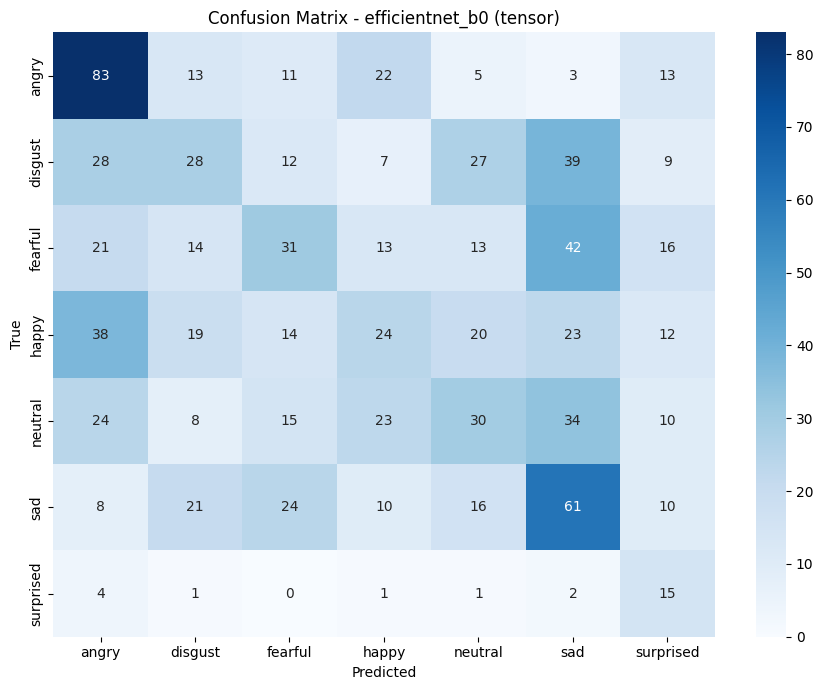

In [16]:

def evaluate_tensor_model_eff(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro')
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model_eff(MODEL_ARCH_1, best_phase2_eff, test_loader, CLASS_NAMES)

### Fine-tuning with ResNet18

In [17]:
set_global_seed(42)
cleanup_state()

In [18]:
MODELS_SAVE_DIR = "/content/saved_models"
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
MODEL_ARCH_2 = 'resnet18'
exp_name_18 = f"tensor_{MODEL_ARCH_2}"

train_loader, val_loader, test_loader, class_names = get_tensors_dataloaders(
    BASE_DIR_TENSOR,
    BATCH_SIZE
)



phase1_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}resnet_fase1.pth")

model = TensorModelFactory.get_model(MODEL_ARCH_2, num_classes=len(CLASS_NAMES), freeze_base=True)

best_fase1_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase1_path,
    epochs=15,
    lr=1e-3,
    patience=4
)

print("Fase 1 mejor modelo:", best_fase1_18)

Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7422 | Val: 830 | Test: 918
Shape ejemplo train[0]: (3, 13, 94) | label=3
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


[01/15] lr=1.0e-03 | train_loss=1.9719 acc=0.2098 | val_loss=1.6907 acc=0.2988 f1m=0.3021
[02/15] lr=1.0e-03 | train_loss=1.7878 acc=0.2738 | val_loss=1.6602 acc=0.3217 f1m=0.3061
[03/15] lr=1.0e-03 | train_loss=1.7373 acc=0.2889 | val_loss=1.6092 acc=0.3663 f1m=0.3550
[04/15] lr=1.0e-03 | train_loss=1.6988 acc=0.3145 | val_loss=1.5805 acc=0.3687 f1m=0.3702
[05/15] lr=1.0e-03 | train_loss=1.6946 acc=0.3189 | val_loss=1.5989 acc=0.3711 f1m=0.3428
Early stop activado: 1/4
[06/15] lr=1.0e-03 | train_loss=1.6868 acc=0.3219 | val_loss=1.5777 acc=0.3711 f1m=0.3666
Early stop activado: 2/4
[07/15] lr=5.0e-04 | train_loss=1.6717 acc=0.3296 | val_loss=1.5864 acc=0.3518 f1m=0.3548
Early stop activado: 3/4
[08/15] lr=5.0e-04 | train_loss=1.6651 acc=0.3312 | val_loss=1.5882 acc=0.3639 f1m=0.3524
Early stop activado: 4/4
Early stopping.
Fase 1 mejor modelo: /content/saved_models/tensor_resnet18resnet_fase1.pth


In [19]:
phase2_path = os.path.join(MODELS_SAVE_DIR, f"{exp_name_18}_phase2_unfrozen.pth")

model.load_state_dict(torch.load(best_fase1_18, map_location=device, weights_only=True))
for p in model.parameters():
    p.requires_grad = True

best_fase2_18 = train_model_tensor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    save_path=phase2_path,
    epochs=25,
    lr=1e-5,
    patience=4
)

print("Fase 2 mejor modelo resnet:", best_fase2_18)

[01/25] lr=1.0e-05 | train_loss=1.6002 acc=0.3645 | val_loss=1.4528 acc=0.4325 f1m=0.4228
[02/25] lr=1.0e-05 | train_loss=1.4290 acc=0.4353 | val_loss=1.3991 acc=0.4735 f1m=0.4665
[03/25] lr=1.0e-05 | train_loss=1.3009 acc=0.5018 | val_loss=1.3689 acc=0.4747 f1m=0.4681
[04/25] lr=1.0e-05 | train_loss=1.1971 acc=0.5485 | val_loss=1.3377 acc=0.4795 f1m=0.4733
[05/25] lr=1.0e-05 | train_loss=1.0845 acc=0.5966 | val_loss=1.3263 acc=0.4819 f1m=0.4820
[06/25] lr=1.0e-05 | train_loss=0.9958 acc=0.6451 | val_loss=1.2975 acc=0.5096 f1m=0.5061
[07/25] lr=1.0e-05 | train_loss=0.8980 acc=0.6851 | val_loss=1.2925 acc=0.5024 f1m=0.5046
Early stop activado: 1/4
[08/25] lr=1.0e-05 | train_loss=0.8041 acc=0.7334 | val_loss=1.2991 acc=0.5012 f1m=0.4963
Early stop activado: 2/4
[09/25] lr=1.0e-05 | train_loss=0.7119 acc=0.7758 | val_loss=1.3087 acc=0.5024 f1m=0.5068
[10/25] lr=1.0e-05 | train_loss=0.6144 acc=0.8213 | val_loss=1.3061 acc=0.5024 f1m=0.5047
Early stop activado: 1/4
[11/25] lr=1.0e-05 | trai

Test Accuracy: 0.4586 | Test F1 macro: 0.4628

              precision    recall  f1-score   support

       angry       0.61      0.71      0.66       150
     disgust       0.35      0.37      0.36       150
     fearful       0.33      0.23      0.27       150
       happy       0.42      0.39      0.40       150
     neutral       0.50      0.44      0.47       144
         sad       0.49      0.55      0.52       150
   surprised       0.43      0.79      0.56        24

    accuracy                           0.46       918
   macro avg       0.45      0.50      0.46       918
weighted avg       0.45      0.46      0.45       918



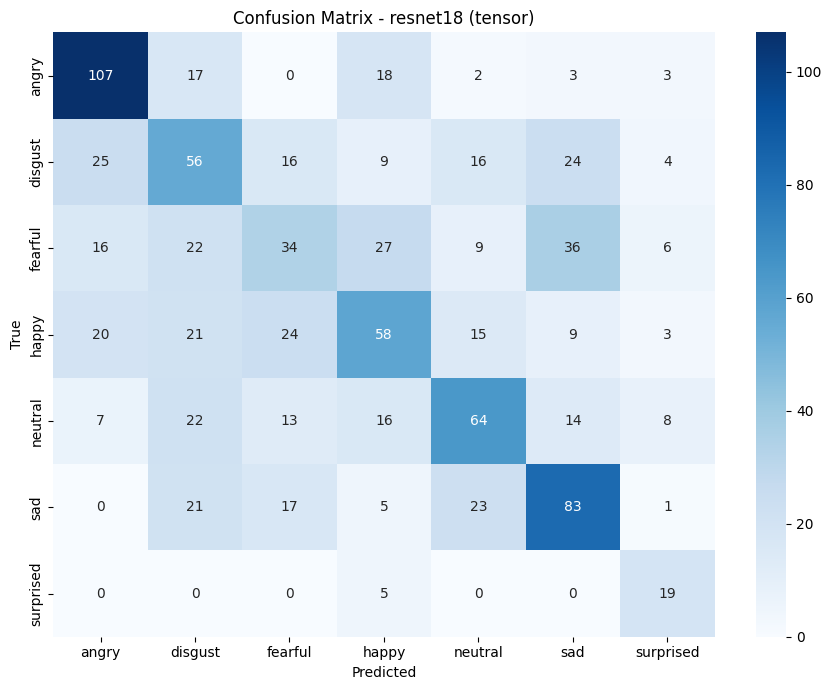

In [20]:
def evaluate_tensor_model(model_arch, model_path, test_loader, class_names):
    model = TensorModelFactory.get_model(model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
            preds = logits.argmax(dim=1)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average='macro')
    print(f"Test Accuracy: {acc:.4f} | Test F1 macro: {f1m:.4f}\n")
    print(classification_report(all_y, all_p, target_names=class_names))

    cm = confusion_matrix(all_y, all_p)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_arch} (tensor)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()

evaluate_tensor_model(MODEL_ARCH_2, best_fase2_18, test_loader, CLASS_NAMES)

### Model Factory for Images

ResNet18 y Efficientnet-b0

In [21]:
set_global_seed(42)
cleanup_state()

In [22]:
class ImageModelFactory:
    @staticmethod
    def get_model(model_name, num_classes, freeze_base=True):
        """
        Instancia dinámicamente arquitecturas convolucionales y adapta la última capa.
        """
        if model_name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.fc.in_features
            model.fc = nn.Sequential(nn.Dropout(0.7), nn.Linear(num_ftrs, num_classes))

        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

        else:
            raise ValueError(f"Arquitectura {model_name} no soportada.")

        return model.to(device)

In [23]:
def train_model(model, train_loader, val_loader, model_save_name, epochs=15, lr=1e-3, patience=5):
    """
    Bucle de entrenamiento con Mixed Precision (AMP) y Early Stopping y LR Scheduler.
    """
    criterion = nn.CrossEntropyLoss()
    # Optimiza solo los parámetros que requieren gradiente (útil en Phase 1)
    # Incrementamos weight_decay a 1e-2 para combatir el Overfitting observado
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-2)

    # Configuramos el LR(Dinamico): Reduce el LR a la mitad si el val_loss no mejora en 2 épocas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    trigger_times = 0
    save_path = os.path.join(MODELS_SAVE_DIR, f'{model_save_name}.pth')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Forward pass con AMP para ahorro de memoria
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Phase de Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Actualizamos el Scheduler basado en la métrica de validación
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{epochs}[LR:{current_lr:.1e}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        else:
            trigger_times += 1
            print(f"Early stop trigger activado {trigger_times} / {patience}")
            if trigger_times >= patience:
                print(f"--> Early Stopping disparado en época {epoch+1}.")
                break

    return save_path

In [24]:

MODES = ['vector', 'png']
TARGET_FEATURE = 'mel_spec' # Opciones: 'mel_spec', 'mfcc'
MODEL_ARCHITECTURE = 'efficientnet_b0' # Opciones: 'resnet18', 'efficientnet_b0'

# Ensure 'device' refers to the torch.device object, not the sklearn function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Carga de datos (usa los DataLoaders optimizados)
print(f"Cargando datos de: {TARGET_FEATURE.upper()}")
train_loader, val_loader, test_loader, class_names = get_images_dataloaders(TARGET_FEATURE)

# 2. Construcción dinámica mediante el Model Factory
model = ImageModelFactory.get_model(model_name=MODEL_ARCHITECTURE, num_classes=len(class_names), freeze_base=True)

experiment_name = f"{TARGET_FEATURE}_{MODEL_ARCHITECTURE}"

# =====================================================================
# FASE 1: TRANSFER LEARNING (Clasificador Superior)
# =====================================================================
print(f"\n--- INICIANDO FASE 1: Entrenando clasificador de {MODEL_ARCHITECTURE} ---")
best_model_path_phase1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase1",
    epochs=15,
    lr=1e-3, # LR más alto porque solo entrenamos la capa lineal final
    patience=4
)

# =====================================================================
# FASE 2: FINE-TUNING PROFUNDO (Descongelamiento)
# =====================================================================
print(f"\n--- INICIANDO FASE 2: Fine-Tuning profundo ---")
# Restauramos el modelo al punto de menor pérdida en la Fase 1
model.load_state_dict(torch.load(best_model_path_phase1, weights_only=True))

# Descongelamos TODOS los pesos para que los filtros convolucionales se adapten al audio
for param in model.parameters():
    param.requires_grad = True

best_model_path_phase2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase2_unfrozen",
    epochs=40,
    lr=1e-5, # CRÍTICO: LR drásticamente más bajo para no destruir los pesos de ImageNet
    patience=4
)

print(f"\nEntrenamiento Finalizado. Mejor modelo guardado en: {best_model_path_phase2}")

Cargando datos de: MEL_SPEC
[MEL_SPEC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895

--- INICIANDO FASE 1: Entrenando clasificador de efficientnet_b0 ---
Epoch 1/15[LR:1.0e-03] | Train Loss: 1.6736 Acc: 0.3247 | Val Loss: 1.5513 Acc: 0.3883
Epoch 2/15[LR:1.0e-03] | Train Loss: 1.5165 Acc: 0.4070 | Val Loss: 1.5039 Acc: 0.4066
Epoch 3/15[LR:1.0e-03] | Train Loss: 1.4786 Acc: 0.4207 | Val Loss: 1.4881 Acc: 0.4041
Epoch 4/15[LR:1.0e-03] | Train Loss: 1.4555 Acc: 0.4296 | Val Loss: 1.4508 Acc: 0.4248
Epoch 5/15[LR:1.0e-03] | Train Loss: 1.4475 Acc: 0.4321 | Val Loss: 1.4620 Acc: 0.4284
Early stop trigger activado 1 / 4
Epoch 6/15[LR:1.0e-03] | Train Loss: 1.4310 Acc: 0.4416 | Val Loss: 1.4559 Acc: 0.4442
Early stop trigger activado 2 / 4
Epoch 7/15[LR:1.0e-03] | Train Loss: 1.4315 Acc: 0.4405 | Val Loss: 1.4305 Acc: 0.4600
Epoch 8/15[LR:1.0e-03] | Train Loss: 1.4314 Acc: 0.4402 | Val Loss: 1.4440 A

Cargando modelo para evaluación: /content/saved_models/mel_spec_efficientnet_b0_phase2_unfrozen.pth

REPORTE DE CLASIFICACIÓN: EFFICIENTNET_B0
              precision    recall  f1-score   support

       angry       0.57      0.74      0.64       144
     disgust       0.49      0.30      0.37       144
     fearful       0.52      0.56      0.54       144
       happy       0.49      0.51      0.50       144
     neutral       0.48      0.62      0.54       143
         sad       0.57      0.38      0.45       144
   surprised       0.69      0.78      0.74        32

    accuracy                           0.53       895
   macro avg       0.55      0.56      0.54       895
weighted avg       0.53      0.53      0.52       895



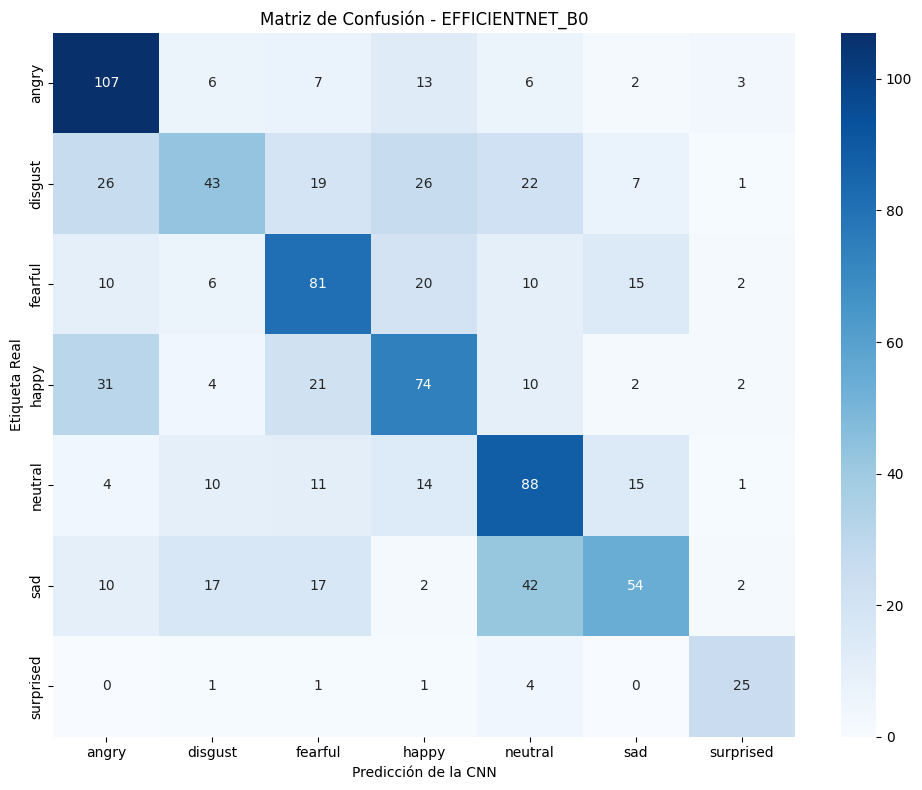

In [25]:
def evaluate_model(model_path, test_loader, class_names, model_arch):
    """
    Carga los pesos de un modelo entrenado, ejecuta inferencia sobre el Test Set
    y genera métricas de clasificación estandarizadas.
    """
    print(f"Cargando modelo para evaluación: {model_path}")

    # Instanciamos una arquitectura vacía (sin congelar nada) y cargamos los pesos finales
    model = ImageModelFactory.get_model(model_name=model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    model.eval() # Modo evaluación: congela capas de Dropout y BatchNorm

    all_preds = []
    all_labels = []

    # Desactivar el tracking de gradientes es obligatorio para liberar VRAM en inferencia
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # AMP también se usa en inferencia para mayor velocidad
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

            # Data Handling: Scikit-learn requiere arrays en CPU y en Numpy
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte Estadístico (F1-Score, Precision, Recall)
    print("\n" + "="*60)
    print(f"REPORTE DE CLASIFICACIÓN: {model_arch.upper()}")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Visualización: Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {model_arch.upper()}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción de la CNN')
    plt.tight_layout()
    plt.show()

    # Memory Management: Limpieza de la GPU tras la inferencia
    del model
    torch.cuda.empty_cache()
    gc.collect()

# Ejecutamos la evaluación con el modelo recién entrenado
evaluate_model(
    model_path=best_model_path_phase2,
    test_loader=test_loader,
    class_names=class_names,
    model_arch=MODEL_ARCHITECTURE
)

Resnet18 con melspec images

In [26]:
set_global_seed(42)
cleanup_state()

In [27]:
MODES = ['vector', 'png']
TARGET_FEATURE = 'mel_spec' # Opciones: 'mel_spec', 'mfcc'
MODEL_ARCHITECTURE = 'resnet18' # Opciones: 'resnet18', 'efficientnet_b0'

# Ensure 'device' refers to the torch.device object, not the sklearn function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Carga de datos (usa los DataLoaders optimizados)
print(f"Cargando datos de: {TARGET_FEATURE.upper()}")
train_loader, val_loader, test_loader, class_names = get_images_dataloaders(TARGET_FEATURE)

# 2. Construcción dinámica mediante el Model Factory
model = ImageModelFactory.get_model(model_name=MODEL_ARCHITECTURE, num_classes=len(class_names), freeze_base=True)

experiment_name = f"{TARGET_FEATURE}_{MODEL_ARCHITECTURE}"

# =====================================================================
# FASE 1: TRANSFER LEARNING (Clasificador Superior)
# =====================================================================
print(f"\n--- INICIANDO FASE 1: Entrenando clasificador de {MODEL_ARCHITECTURE} ---")
best_model_path_phase1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase1",
    epochs=15,
    lr=1e-3, # LR más alto porque solo entrenamos la capa lineal final
    patience=4
)

# =====================================================================
# FASE 2: FINE-TUNING PROFUNDO (Descongelamiento)
# =====================================================================
print(f"\n--- INICIANDO FASE 2: Fine-Tuning profundo ---")
# Restauramos el modelo al punto de menor pérdida en la Fase 1
model.load_state_dict(torch.load(best_model_path_phase1, weights_only=True))

# Descongelamos TODOS los pesos para que los filtros convolucionales se adapten al audio
for param in model.parameters():
    param.requires_grad = True

best_model_path_phase2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase2_unfrozen",
    epochs=40,
    lr=1e-5, # CRÍTICO: LR drásticamente más bajo para no destruir los pesos de ImageNet
    patience=4
)

print(f"\nEntrenamiento Finalizado. Mejor modelo guardado en: {best_model_path_phase2}")

Cargando datos de: MEL_SPEC
[MEL_SPEC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895

--- INICIANDO FASE 1: Entrenando clasificador de resnet18 ---
Epoch 1/15[LR:1.0e-03] | Train Loss: 2.0140 Acc: 0.2276 | Val Loss: 1.6041 Acc: 0.3871
Epoch 2/15[LR:1.0e-03] | Train Loss: 1.7442 Acc: 0.3091 | Val Loss: 1.5604 Acc: 0.3665
Epoch 3/15[LR:1.0e-03] | Train Loss: 1.6871 Acc: 0.3326 | Val Loss: 1.5179 Acc: 0.4211
Epoch 4/15[LR:1.0e-03] | Train Loss: 1.6658 Acc: 0.3389 | Val Loss: 1.5457 Acc: 0.3968
Early stop trigger activado 1 / 4
Epoch 5/15[LR:1.0e-03] | Train Loss: 1.6706 Acc: 0.3365 | Val Loss: 1.5351 Acc: 0.4090
Early stop trigger activado 2 / 4
Epoch 6/15[LR:1.0e-03] | Train Loss: 1.6653 Acc: 0.3361 | Val Loss: 1.5098 Acc: 0.4466
Epoch 7/15[LR:1.0e-03] | Train Loss: 1.6475 Acc: 0.3411 | Val Loss: 1.5065 Acc: 0.4248
Epoch 8/15[LR:1.0e-03] | Train Loss: 1.6600 Acc: 0.3357 | Val Loss: 1.4978 Acc: 0.4

Cargando modelo para evaluación: /content/saved_models/mel_spec_resnet18_phase2_unfrozen.pth

REPORTE DE CLASIFICACIÓN: RESNET18
              precision    recall  f1-score   support

       angry       0.60      0.76      0.67       144
     disgust       0.48      0.29      0.36       144
     fearful       0.52      0.60      0.55       144
       happy       0.59      0.55      0.57       144
     neutral       0.52      0.70      0.60       143
         sad       0.57      0.42      0.48       144
   surprised       0.86      0.75      0.80        32

    accuracy                           0.56       895
   macro avg       0.59      0.58      0.58       895
weighted avg       0.56      0.56      0.55       895



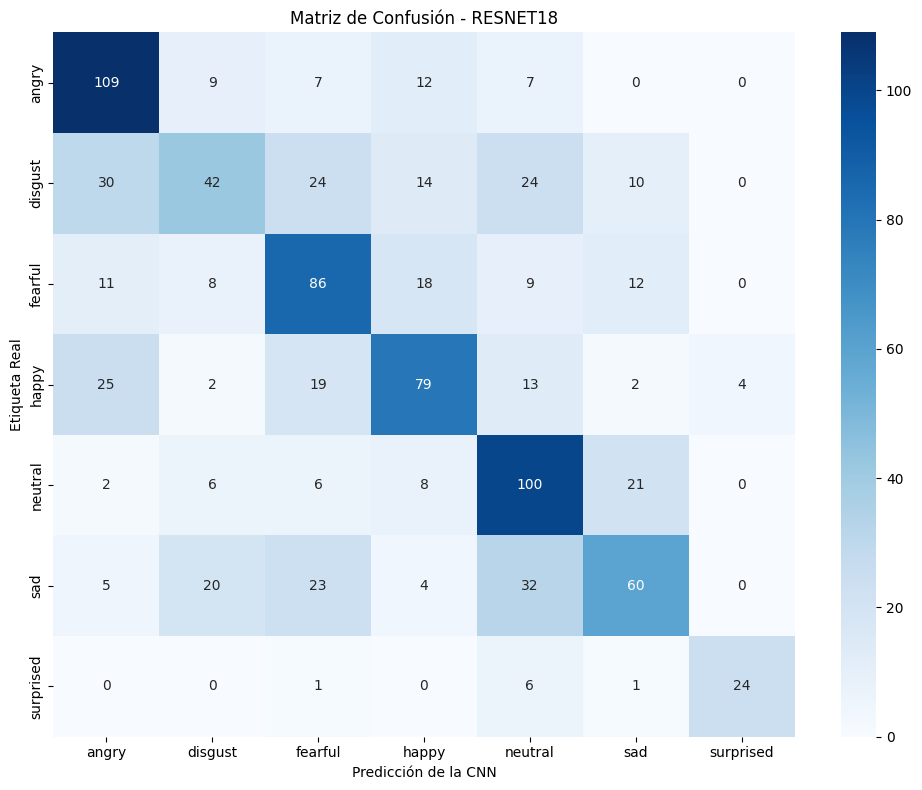

In [28]:
def evaluate_model(model_path, test_loader, class_names, model_arch):
    """
    Carga los pesos de un modelo entrenado, ejecuta inferencia sobre el Test Set
    y genera métricas de clasificación estandarizadas.
    """
    print(f"Cargando modelo para evaluación: {model_path}")

    # Instanciamos una arquitectura vacía (sin congelar nada) y cargamos los pesos finales
    model = ImageModelFactory.get_model(model_name=model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    model.eval() # Modo evaluación: congela capas de Dropout y BatchNorm

    all_preds = []
    all_labels = []

    # Desactivar el tracking de gradientes es obligatorio para liberar VRAM en inferencia
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # AMP también se usa en inferencia para mayor velocidad
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

            # Data Handling: Scikit-learn requiere arrays en CPU y en Numpy
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte Estadístico (F1-Score, Precision, Recall)
    print("\n" + "="*60)
    print(f"REPORTE DE CLASIFICACIÓN: {model_arch.upper()}")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Visualización: Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {model_arch.upper()}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción de la CNN')
    plt.tight_layout()
    plt.show()

    # Memory Management: Limpieza de la GPU tras la inferencia
    del model
    torch.cuda.empty_cache()
    gc.collect()

# Ejecutamos la evaluación con el modelo recién entrenado
evaluate_model(
    model_path=best_model_path_phase2,
    test_loader=test_loader,
    class_names=class_names,
    model_arch=MODEL_ARCHITECTURE
)

In [30]:
import shutil
# Save the models for the next stage (late fusion)
output_filename = '/content/saved_models'
shutil.make_archive(output_filename, 'zip', MODELS_SAVE_DIR)

# Rename the zip file so it has the .zip extension
# This is a workaround for make_archive, which does not add the extension by default if base_name already looks like one.
import os
os.rename('/content/saved_models.zip', '/content/saved_models_final.zip')

!cp /content/saved_models_final.zip /content/drive/MyDrive/saved_models_img_and_tensor.zip